# HerdGuard AI – Early Mastitis Risk Prediction

### Smart India Hackathon 2026

This notebook develops a prototype AI model for predicting
subclinical mastitis risk in dairy cattle 7 and 14 days in advance.

The model uses cow-level sensor, farm and health-related features
and provides explainable risk predictions using SHAP.

## 1. Environment Setup


This section installs and imports the Python libraries required for
data processing, machine learning and explainable AI.

### Main Libraries

- **Pandas** — data manipulation and analysis
- **NumPy** — numerical computation
- **Matplotlib** — visualization
- **Scikit-learn** — preprocessing and model evaluation
- **XGBoost** — gradient-boosted classification
- **SHAP** — explainable AI and feature contribution analysis

In [83]:
!pip install -q xgboost shap

## 2. Initial Dataset Exploration
The first dataset is used to establish an initial machine-learning
baseline for mastitis classification.

It contains cow-level milk and health-related measurements such as:

- Milk temperature
- Milk pH
- Milk conductivity
- Somatic cell count
- Milk yield
- Clotting
- Mastitis class label

The purpose of this stage is to understand the structure of the
available data and establish an initial proof-of-concept baseline
before developing the longitudinal HerdGuard approach.

In [84]:
import pandas as pd

df = pd.read_csv('/content/cow_milk_mastitis_dataset.csv')

print("Dataset loaded!")
print("Shape:", df.shape)

df.head()

Dataset loaded!
Shape: (800, 9)


,Cow_ID,Day,Milk_Temperature,Milk_pH,Milk_Conductivity,Somatic_Cell_Count,Milk_Yield,Clotting,class1
0,C0001,7,35.38,6.49,4.68,148,17.3,0,0
1,C0002,20,35.68,6.46,5.04,101,20.4,0,0
2,C0003,29,34.87,6.84,4.73,206,18.5,0,0
3,C0004,15,36.22,6.69,4.48,96,23.5,0,0
4,C0005,11,35.46,6.56,5.00,142,23.9,0,0


## 3. Dataset Analysis / Initial Observations

The initial dataset is examined to understand how the available
measurements differ between the healthy and mastitis classes.

The analysis focuses on:

- Average sensor and milk-related measurements for each class
- The relationship between clotting and the mastitis label
- Somatic Cell Count (SCC) statistics across the two classes
- Potentially target-associated features that may make the dataset
  highly separable

This analysis is performed before selecting the features for the
sensor-focused experiment.

The objective is to understand the characteristics and limitations of
the initial dataset rather than assuming that very high model
performance automatically represents real-world clinical performance.

In [85]:
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["class1"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cow_ID              800 non-null    object 
 1   Day                 800 non-null    int64  
 2   Milk_Temperature    800 non-null    float64
 3   Milk_pH             800 non-null    float64
 4   Milk_Conductivity   800 non-null    float64
 5   Somatic_Cell_Count  800 non-null    int64  
 6   Milk_Yield          800 non-null    float64
 7   Clotting            800 non-null    int64  
 8   class1              800 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 56.4+ KB
None

Missing values:
Cow_ID                0
Day                   0
Milk_Temperature      0
Milk_pH               0
Milk_Conductivity     0
Somatic_Cell_Count    0
Milk_Yield            0
Clotting              0
class1                0
dtype: int64

Target distribution:


## 4. Baseline Model
[code cell]
X = ...
y = ...

[output]

[next code cell]
from sklearn.model_selection import train_test_split

In [86]:
# Separate input features (X) and target (y)

X = df.drop(columns=['Cow_ID', 'class1'])
y = df['class1']

print("Features used for training:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.value_counts())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used for training:
['Day', 'Milk_Temperature', 'Milk_pH', 'Milk_Conductivity', 'Somatic_Cell_Count', 'Milk_Yield', 'Clotting']

Target classes:
class1
0    631
1    169
Name: count, dtype: int64

X shape: (800, 7)
y shape: (800,)


###  Train/Test Split
The dataset is divided into training and testing subsets using an
80:20 split.

A stratified split is used so that the proportion of healthy and
mastitis observations remains similar in both subsets.

The training set is used to learn the relationship between the input
features and mastitis class, while the testing set is reserved for
evaluating the model on unseen observations.

A fixed random state is used to make the experiment reproducible.

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 640
Testing samples: 160

Training class distribution:
class1
0    505
1    135
Name: count, dtype: int64

Testing class distribution:
class1
0    126
1     34
Name: count, dtype: int64


###  Logistic Regression Baseline
Logistic Regression is used as a simple baseline classifier for the
initial dataset.

The model learns the relationship between the selected input features
and the mastitis class using the training data.

This baseline provides a reference point for evaluating the more
advanced XGBoost model used later in the HerdGuard pipeline.

In [88]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## Baseline Model Evaluation
The trained Logistic Regression model is evaluated on the unseen test
data.

The following metrics are calculated:

- **Accuracy** — overall proportion of correct predictions
- **Precision** — proportion of predicted mastitis cases that are
  actually mastitis cases
- **Recall** — proportion of actual mastitis cases detected by the model
- **F1 Score** — balance between precision and recall
- **ROC-AUC** — ability of the model to distinguish between the two
  classes across different decision thresholds

These metrics establish the baseline performance before moving to
XGBoost.

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Results
---------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


## 5. Dataset Analysis and Limitations
The initial Logistic Regression model produces very high classification
performance. Before interpreting these results, the underlying dataset
is examined to understand how strongly the input features are associated
with the mastitis class.

The analysis compares average feature values between the two classes and
examines the relationship between clotting, somatic cell count (SCC),
and the target label.

This helps identify features that may provide unusually strong class
separation and could make the dataset less representative of a
real-world prediction scenario.

In [90]:
print("Average values by class:")
print(df.groupby("class1")[
    ["Milk_Temperature",
     "Milk_pH",
     "Milk_Conductivity",
     "Somatic_Cell_Count",
     "Milk_Yield",
     "Clotting"]
].mean())

print("\nClotting vs Mastitis:")
print(pd.crosstab(df["Clotting"], df["class1"]))

print("\nSCC statistics by class:")
print(df.groupby("class1")["Somatic_Cell_Count"].describe())

Average values by class:
        Milk_Temperature   Milk_pH  Milk_Conductivity  Somatic_Cell_Count  \
class1                                                                      
0              35.540998  6.646529           4.688526          147.993661   
1              38.050592  7.109941           6.779527          598.053254   

        Milk_Yield  Clotting  
class1                        
0        20.148019  0.000000  
1         9.353846  0.816568  

Clotting vs Mastitis:
class1      0    1
Clotting          
0         631   31
1           0  138

SCC statistics by class:
        count        mean         std    min    25%    50%    75%     max
class1                                                                   
0       631.0  147.993661   41.078051   34.0  118.5  148.0  177.0   274.0
1       169.0  598.053254  127.275819  235.0  509.0  591.0  675.0  1023.0


## Removing Leakage-Prone Features
The previous analysis showed that some variables have a very strong
relationship with the mastitis label.

Somatic Cell Count and clotting are therefore removed from this
sensor-focused experiment because they can provide information that is
closely associated with the current mastitis condition.

The `Day` column is also excluded because it represents the observation
index rather than a direct physiological measurement.

The model is therefore restricted to four measurable milk-related
features:

- Milk temperature
- Milk pH
- Milk conductivity
- Milk yield

This experiment provides a cleaner baseline for evaluating whether the
remaining measurements can distinguish between the two classes.

In [91]:
# Remove features that can directly reveal the current mastitis label

X_realistic = df[
    [
        'Milk_Temperature',
        'Milk_pH',
        'Milk_Conductivity',
        'Milk_Yield'
    ]
]

y = df['class1']

print("Features used in realistic model:")
print(X_realistic.columns.tolist())

print("\nShape:", X_realistic.shape)

Features used in realistic model:
['Milk_Temperature', 'Milk_pH', 'Milk_Conductivity', 'Milk_Yield']

Shape: (800, 4)


##  Train/Test Split for the Sensor-Focused Model
The cleaned feature set is divided into training and testing subsets
using the same stratified 80:20 split.

Stratification preserves the class distribution in both subsets,
allowing the sensor-focused experiment to be compared consistently
with the initial baseline.

In [92]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_realistic,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_r))
print("Testing samples:", len(X_test_r))

print("\nTraining classes:")
print(y_train_r.value_counts())

print("\nTesting classes:")
print(y_test_r.value_counts())

Training samples: 640
Testing samples: 160

Training classes:
class1
0    505
1    135
Name: count, dtype: int64

Testing classes:
class1
0    126
1     34
Name: count, dtype: int64


## Sensor-Focused Logistic Regression
A second Logistic Regression model is trained using only the four
sensor-related features selected in the previous step.

This experiment evaluates whether the model can still distinguish
between the two classes after removing the strongly target-associated
variables.

The result is used as a cleaner baseline before introducing the
longitudinal HerdGuard approach.

In [93]:
logistic_realistic = LogisticRegression(max_iter=1000)

logistic_realistic.fit(X_train_r, y_train_r)

print("Realistic Logistic Regression trained successfully!")

Realistic Logistic Regression trained successfully!


## Sensor-Focused Model Evaluation
The cleaned Logistic Regression model is evaluated on the held-out
test set using the same performance metrics as the initial baseline.

Comparing these results with the original model helps determine how
much the excluded features contributed to the initial classification
performance.

Because the dataset remains synthetic and highly separable, these
results should be interpreted as a proof-of-concept rather than
real-world clinical performance

In [94]:
y_pred_realistic = logistic_realistic.predict(X_test_r)
y_prob_realistic = logistic_realistic.predict_proba(X_test_r)[:, 1]

print("Realistic Logistic Regression Results")
print("-------------------------------------")
print("Accuracy :", accuracy_score(y_test_r, y_pred_realistic))
print("Precision:", precision_score(y_test_r, y_pred_realistic))
print("Recall   :", recall_score(y_test_r, y_pred_realistic))
print("F1 Score :", f1_score(y_test_r, y_pred_realistic))
print("ROC-AUC  :", roc_auc_score(y_test_r, y_prob_realistic))

Realistic Logistic Regression Results
-------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


## 6. Baseline XGBoost Model
XGBoost is selected as the primary machine-learning algorithm for the
HerdGuard prototype.

XGBoost is a gradient-boosted decision-tree model that is well suited
for structured tabular data and can capture nonlinear relationships
between sensor measurements and mastitis risk.

The model is trained using the cleaned sensor-focused feature set:

- Milk temperature
- Milk pH
- Milk conductivity
- Milk yield

The parameters below provide a lightweight baseline configuration
while controlling model complexity and improving reproducibility.

In [95]:
# HerdGuard XGBoost Model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_r, y_train_r)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


##  Baseline XGBoost Evaluation
The trained XGBoost model is evaluated on the held-out test set.

The same evaluation metrics used for the Logistic Regression baseline
are calculated:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **ROC-AUC**

Using the same test set and metrics allows the XGBoost results to be
compared with the earlier baseline experiment.

> **Note:** The dataset is synthetic and highly separable. Therefore,
> these results demonstrate the behaviour of the prototype model and
> should not be interpreted as clinical validation.


In [96]:
# Evaluate XGBoost Model
y_pred_xgb = xgb_model.predict(X_test_r)
y_prob_xgb = xgb_model.predict_proba(X_test_r)[:, 1]
print("XGBoost Results")
print("----------------")
print("Accuracy :", accuracy_score(y_test_r, y_pred_xgb))
print("Precision:", precision_score(y_test_r, y_pred_xgb))
print("Recall   :", recall_score(y_test_r, y_pred_xgb))
print("F1 Score :", f1_score(y_test_r, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test_r, y_prob_xgb))

XGBoost Results
----------------
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.9411764705882353
F1 Score : 0.9696969696969697
ROC-AUC  : 1.0


## 7. SHAP Explainability — Baseline Model
SHAP (SHapley Additive exPlanations) is used to interpret the
predictions produced by the XGBoost model.

While the model provides a predicted mastitis class or probability,
SHAP helps identify which input features contributed most strongly to
those predictions.

This provides an explainable layer for the HerdGuard prototype and
helps move from a simple risk prediction toward an explanation of the
factors influencing that prediction.

In [97]:
# SHAP Explainability
import shap
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_r)

print("SHAP explanation generated successfully!")

SHAP explanation generated successfully!


## SHAP Impact Direction
The SHAP feature-importance plot summarizes the average contribution of
each input feature across the test observations.

Features with larger absolute SHAP contributions have a greater
influence on the model's predictions.

This provides a global view of which sensor measurements the baseline
XGBoost model relies on most strongly.

/tmp/ipykernel_622/980665385.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


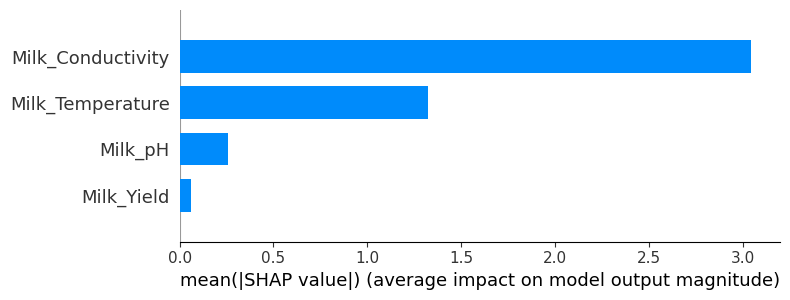

In [98]:
# SHAP Feature Importance

shap.summary_plot(
    shap_values,
    X_test_r,
    plot_type="bar"
)

## 8. Synthetic Longitudinal Herd Dataset
The next stage moves from a static cow-level dataset to a longitudinal
demonstration dataset.

The synthetic dataset represents:

- **80 cows**
- **90 days**
- **7,200 cow-day observations**

Each cow is assigned individual characteristics and baseline sensor
behaviour.

The simulated measurements include:

- Body temperature
- Activity
- Rumination
- Milk conductivity
- Milk yield
- Shed temperature
- Humidity
- Breed
- Age
- Days in milk

A subset of cows is simulated with gradually increasing abnormal
sensor behaviour.

> **Important:** This dataset is synthetic and is used only to
> demonstrate the proposed HerdGuard machine-learning workflow. It is
> not a clinical dataset and does not establish real-world diagnostic
> performance.


In [99]:


import numpy as np
import pandas as pd

np.random.seed(42)

N_COWS = 80
N_DAYS = 90

cow_ids = [f"COW-{i:03d}" for i in range(1, N_COWS + 1)]

# Cow characteristics
breeds = np.random.choice(
    ["HF Cross", "Jersey Cross", "Gir", "Murrah"],
    N_COWS,
    p=[0.40, 0.30, 0.15, 0.15]
)

species = np.where(
    np.isin(breeds, ["Murrah"]),
    "Buffalo",
    "Cattle"
)

age = np.random.randint(2, 9, N_COWS)
days_in_milk = np.random.randint(20, 280, N_COWS)

# Individual cow normal baselines
base_temp = np.random.normal(38.5, 0.18, N_COWS)
base_activity = np.random.normal(95, 8, N_COWS)
base_rumination = np.random.normal(470, 35, N_COWS)
base_conductivity = np.random.normal(4.8, 0.35, N_COWS)
base_yield = np.random.normal(13, 2.5, N_COWS)

records = []

# Some cows will develop increasing abnormalities
high_risk_cows = np.random.choice(
    np.arange(N_COWS),
    size=14,
    replace=False
)

for day in range(N_DAYS):

    date = pd.Timestamp("2026-07-01") + pd.Timedelta(days=day)

    # Farm environment
    farm_temp = 27 + 3 * np.sin(day / 12) + np.random.normal(0, 0.8)
    humidity = 65 + 8 * np.sin(day / 15) + np.random.normal(0, 3)

    for i, cow in enumerate(cow_ids):

        disease_progression = 0

        # Abnormality gradually develops after day 48
        if i in high_risk_cows and day > 48:
            disease_progression = min(
                1,
                (day - 48) / 30
            )

        # Sensor measurements
        temperature = (
            base_temp[i]
            + 0.05 * disease_progression
            + np.random.normal(0, 0.06)
        )

        activity = (
            base_activity[i]
            - 20 * disease_progression
            + np.random.normal(0, 4)
        )

        rumination = (
            base_rumination[i]
            - 95 * disease_progression
            + np.random.normal(0, 12)
        )

        conductivity = (
            base_conductivity[i]
            + 1.8 * disease_progression
            + np.random.normal(0, 0.15)
        )

        milk_yield = (
            base_yield[i]
            - 3.0 * disease_progression
            + np.random.normal(0, 0.5)
        )

        # Synthetic underlying mastitis signal
        scc_signal = (
            0.65 * (conductivity - base_conductivity[i])
            + 0.25 * (temperature - base_temp[i])
            - 0.20 * (activity - base_activity[i]) / 10
            - 0.20 * (rumination - base_rumination[i]) / 30
            + np.random.normal(0, 0.08)
        )

        # Synthetic demonstration label
        mastitis_event = int(scc_signal > 0.55)

        records.append([
            date,
            cow,
            species[i],
            breeds[i],
            age[i],
            days_in_milk[i],
            temperature,
            activity,
            rumination,
            conductivity,
            milk_yield,
            farm_temp,
            humidity,
            mastitis_event
        ])

# Create dataframe
synthetic_df = pd.DataFrame(
    records,
    columns=[
        "date",
        "cow_id",
        "species",
        "breed",
        "age",
        "days_in_milk",
        "temperature",
        "activity",
        "rumination",
        "conductivity",
        "milk_yield",
        "shed_temperature",
        "humidity",
        "mastitis_event"
    ]
)

print("Synthetic dataset created successfully!")
print("Shape:", synthetic_df.shape)
print("Number of cows:", synthetic_df["cow_id"].nunique())
print("Number of days:", synthetic_df["date"].nunique())

synthetic_df.head()

Synthetic dataset created successfully!
Shape: (7200, 14)
Number of cows: 80
Number of days: 90


,date,cow_id,species,breed,age,days_in_milk,temperature,activity,rumination,conductivity,milk_yield,shed_temperature,humidity,mastitis_event
0,2026-07-01,COW-001,Cattle,HF Cross,8,140,38.579994,105.685145,540.290741,4.521618,13.755613,25.577024,69.488133,0
1,2026-07-01,COW-002,Buffalo,Murrah,2,135,38.659096,104.533194,513.055059,4.273889,12.485286,25.577024,69.488133,0
2,2026-07-01,COW-003,Cattle,Gir,5,252,38.644391,100.502826,426.396661,4.244311,9.852041,25.577024,69.488133,0
3,2026-07-01,COW-004,Cattle,Jersey Cross,3,278,38.284310,102.913358,434.053352,5.216855,11.285063,25.577024,69.488133,0
4,2026-07-01,COW-005,Cattle,HF Cross,2,217,38.628156,96.764731,522.050349,5.182154,10.421957,25.577024,69.488133,0


## 9. Per-Cow Baseline
Different cows naturally have different normal physiological and
behavioural ranges.

Instead of comparing every cow against a single population average,
HerdGuard establishes an individual baseline for each cow.

For each cow, the average values of:

- Temperature
- Activity
- Rumination
- Conductivity
- Milk yield

are calculated over the available demonstration period.

These baseline values are then attached to each observation for that
cow.

This allows later stages of the pipeline to measure whether a cow's
current sensor behaviour is deviating from its own normal pattern.

In [100]:
# Create individual cow baselines

baseline = (
    synthetic_df.groupby("cow_id")[
        [
            "temperature",
            "activity",
            "rumination",
            "conductivity",
            "milk_yield"
        ]
    ]
    .mean()
    .add_prefix("baseline_")
    .reset_index()
)

# Remove old baseline columns if they already exist
old_baseline_cols = [
    "baseline_temperature",
    "baseline_activity",
    "baseline_rumination",
    "baseline_conductivity",
    "baseline_milk_yield"
]

synthetic_df = synthetic_df.drop(
    columns=[col for col in old_baseline_cols if col in synthetic_df.columns],
    errors="ignore"
)

# Merge baselines back into the original dataset
synthetic_df = synthetic_df.merge(
    baseline,
    on="cow_id",
    how="left"
)

print("Baseline columns created successfully:")
print([
    "baseline_temperature",
    "baseline_activity",
    "baseline_rumination",
    "baseline_conductivity",
    "baseline_milk_yield"
])

print("\nDataset shape:", synthetic_df.shape)

Baseline columns created successfully:
['baseline_temperature', 'baseline_activity', 'baseline_rumination', 'baseline_conductivity', 'baseline_milk_yield']

Dataset shape: (7200, 19)


## 10. Feature Normalization
The anomaly features have different numerical scales.

For example, activity and rumination may change by tens of units,
while temperature may change by only a fraction of a degree.

Standardization converts these deviations into comparable normalized
scores.

A z-score indicates how far an observation is from the overall
distribution of that anomaly feature.

The normalized features are then used as inputs to the longitudinal
XGBoost model.

In [101]:
# Create anomaly / deviation features

synthetic_df["temp_change"] = (
    synthetic_df["temperature"]
    - synthetic_df["baseline_temperature"]
)

synthetic_df["activity_drop"] = (
    synthetic_df["baseline_activity"]
    - synthetic_df["activity"]
)

synthetic_df["rumination_drop"] = (
    synthetic_df["baseline_rumination"]
    - synthetic_df["rumination"]
)

synthetic_df["conductivity_rise"] = (
    synthetic_df["conductivity"]
    - synthetic_df["baseline_conductivity"]
)

synthetic_df["yield_drop"] = (
    synthetic_df["baseline_milk_yield"]
    - synthetic_df["milk_yield"]
)

print("Anomaly features created successfully!")

print(
    synthetic_df[
        [
            "cow_id",
            "temp_change",
            "activity_drop",
            "rumination_drop",
            "conductivity_rise",
            "yield_drop"
        ]
    ].head()
)

Anomaly features created successfully!
    cow_id  temp_change  activity_drop  rumination_drop  conductivity_rise  \
0  COW-001     0.039499       0.208030        -2.994769          -0.151883   
1  COW-002     0.009331      -2.759115        -6.404095           0.056908   
2  COW-003     0.106184      -5.570452       -18.850775          -0.068494   
3  COW-004     0.014782      -4.656307        19.027782           0.244381   
4  COW-005    -0.055936       6.517242       -10.947076           0.000537   

   yield_drop  
0   -1.216015  
1    0.250138  
2    0.396512  
3    0.112439  
4    0.618705  


## 11. Time-Based Train/Test Split
Because HerdGuard is intended to predict future risk, a random
train/test split would not accurately represent the intended deployment
scenario.

Instead, the longitudinal dataset is divided chronologically:

- Earlier observations are used for training.
- The final 20 days are held out for testing.

This simulates a real-world situation in which historical observations
are used to train a model and later observations are used to evaluate
performance on future observations.

The chronological split also helps prevent information from later
observations from being randomly mixed into the training data.

In [102]:
# ============================================================
# HERDGUARD - REBUILD BASELINE + ANOMALY + NORMALIZED FEATURES
# ============================================================

# Make sure date is datetime
synthetic_df["date"] = pd.to_datetime(synthetic_df["date"])


# ------------------------------------------------------------
# 1. Create individual cow baselines
# ------------------------------------------------------------

baseline = (
    synthetic_df.groupby("cow_id")[
        [
            "temperature",
            "activity",
            "rumination",
            "conductivity",
            "milk_yield"
        ]
    ]
    .mean()
    .add_prefix("baseline_")
    .reset_index()
)


# Remove old baseline columns if they exist
baseline_columns = [
    "baseline_temperature",
    "baseline_activity",
    "baseline_rumination",
    "baseline_conductivity",
    "baseline_milk_yield"
]

synthetic_df = synthetic_df.drop(
    columns=[
        col for col in baseline_columns
        if col in synthetic_df.columns
    ],
    errors="ignore"
)


# Merge the baselines back into the dataset
synthetic_df = synthetic_df.merge(
    baseline,
    on="cow_id",
    how="left"
)


# ------------------------------------------------------------
# 2. Create anomaly / deviation features
# ------------------------------------------------------------

synthetic_df["temp_change"] = (
    synthetic_df["temperature"]
    - synthetic_df["baseline_temperature"]
)

synthetic_df["activity_drop"] = (
    synthetic_df["baseline_activity"]
    - synthetic_df["activity"]
)

synthetic_df["rumination_drop"] = (
    synthetic_df["baseline_rumination"]
    - synthetic_df["rumination"]
)

synthetic_df["conductivity_rise"] = (
    synthetic_df["conductivity"]
    - synthetic_df["baseline_conductivity"]
)

synthetic_df["yield_drop"] = (
    synthetic_df["baseline_milk_yield"]
    - synthetic_df["milk_yield"]
)


# ------------------------------------------------------------
# 3. Normalize anomaly features
# ------------------------------------------------------------

def normalize(series):
    std = series.std()

    if std == 0:
        return series * 0

    return (series - series.mean()) / std


synthetic_df["z_temp"] = normalize(
    synthetic_df["temp_change"]
)

synthetic_df["z_activity"] = normalize(
    synthetic_df["activity_drop"]
)

synthetic_df["z_rumination"] = normalize(
    synthetic_df["rumination_drop"]
)

synthetic_df["z_conductivity"] = normalize(
    synthetic_df["conductivity_rise"]
)

synthetic_df["z_yield"] = normalize(
    synthetic_df["yield_drop"]
)


# ------------------------------------------------------------
# 4. Verify
# ------------------------------------------------------------

model_features = [
    "z_temp",
    "z_activity",
    "z_rumination",
    "z_conductivity",
    "z_yield"
]

missing = [
    col for col in model_features
    if col not in synthetic_df.columns
]

if len(missing) == 0:

    print("========================================")
    print("SUCCESS!")
    print("========================================")
    print("All normalized model features exist.")

    print("\nModel features:")
    print(model_features)

    print("\nDataset shape:")
    print(synthetic_df.shape)

    print("\nSample:")
    print(
        synthetic_df[
            ["cow_id"] + model_features
        ].head()
    )

else:

    print("ERROR!")
    print("Missing columns:")
    print(missing)

SUCCESS!
All normalized model features exist.

Model features:
['z_temp', 'z_activity', 'z_rumination', 'z_conductivity', 'z_yield']

Dataset shape:
(7200, 29)

Sample:
    cow_id    z_temp  z_activity  z_rumination  z_conductivity   z_yield
0  COW-001  0.644701    0.040065     -0.153093       -0.462802 -1.744367
1  COW-002  0.152296   -0.531382     -0.327378        0.173402  0.358821
2  COW-003  1.733126   -1.072822     -0.963654       -0.208706  0.568794
3  COW-004  0.241269   -0.896765      0.972703        0.744651  0.161293
4  COW-005 -0.912990    1.255165     -0.559616        0.001635  0.887529


## 12. Longitudinal XGBoost
The primary HerdGuard demonstration model is trained using the
individual-cow anomaly features generated from the longitudinal
dataset.

The model inputs are:

- Normalized temperature deviation
- Normalized activity deviation
- Normalized rumination deviation
- Normalized conductivity deviation
- Normalized milk-yield deviation

XGBoost is used to learn the relationship between these sensor
deviations and the synthetic mastitis-event label.

The model is trained only on the earlier observations defined by the
time-based training split, while the later observations are reserved
for evaluation.

In [103]:


from xgboost import XGBClassifier

xgb_long = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_long.fit(
    X_train_long,
    y_train_long
)

print("Longitudinal XGBoost model trained successfully!")

Longitudinal XGBoost model trained successfully!


## Longitudinal Model Evaluation
The trained longitudinal XGBoost model is evaluated on the held-out
future observations.

The evaluation includes:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **ROC-AUC**
- **Confusion Matrix**

These metrics describe how well the prototype distinguishes the
synthetic mastitis-event observations from normal observations in the
held-out period.

> **Important:** The longitudinal dataset and labels are synthetic.
> Therefore, these results demonstrate the machine-learning pipeline
> and are not clinical validation results.

In [104]:


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred_long = xgb_long.predict(X_test_long)
y_prob_long = xgb_long.predict_proba(X_test_long)[:, 1]

print("Longitudinal XGBoost Results")
print("----------------------------")
print("Accuracy :", accuracy_score(y_test_long, y_pred_long))
print("Precision:", precision_score(y_test_long, y_pred_long, zero_division=0))
print("Recall   :", recall_score(y_test_long, y_pred_long, zero_division=0))
print("F1 Score :", f1_score(y_test_long, y_pred_long, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test_long, y_prob_long))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_long, y_pred_long))

Longitudinal XGBoost Results
----------------------------
Accuracy : 0.998125
Precision: 0.9929078014184397
Recall   : 0.99644128113879
F1 Score : 0.9946714031971581
ROC-AUC  : 0.9999757176120161

Confusion Matrix:
[[1317    2]
 [   1  280]]


## 13. SHAP Explainability — Longitudinal Model
SHAP is applied to the final longitudinal XGBoost model to identify
which anomaly features contribute most strongly to its predictions.

This provides an explainable layer for the HerdGuard risk engine.

The objective is to move from a simple prediction such as:

**"This cow is high risk."**

to an explanation such as:

**"This cow is high risk because specific sensor measurements have
deviated from its normal baseline."**

The SHAP analysis is performed both globally, to understand overall
model behaviour, and for individual cows, to explain specific
predictions.

/tmp/ipykernel_622/71853133.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


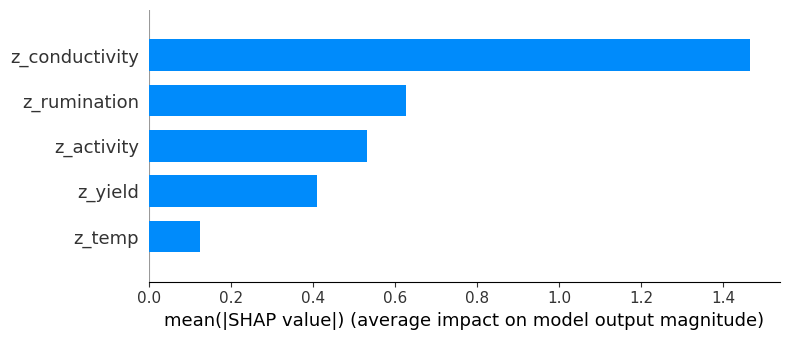

/tmp/ipykernel_622/71853133.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


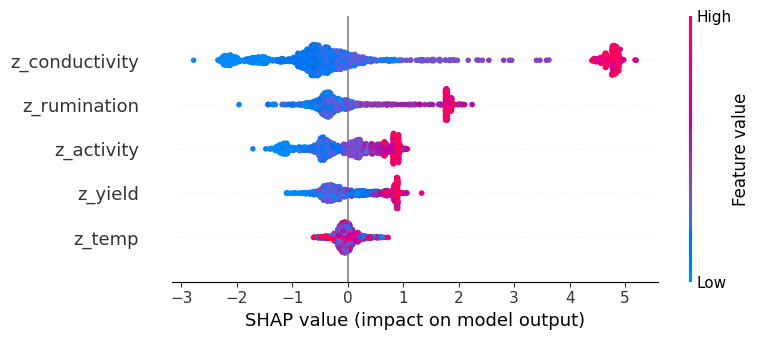

Risk classification generated successfully!
       cow_id       date  risk_score risk_level
7190  COW-071 2026-09-28   99.235519       High
7191  COW-072 2026-09-28    2.349588    No Risk
7192  COW-073 2026-09-28    3.785165    No Risk
7193  COW-074 2026-09-28    2.069459    No Risk
7194  COW-075 2026-09-28    0.100277    No Risk
7195  COW-076 2026-09-28   99.354362       High
7196  COW-077 2026-09-28    2.054760    No Risk
7197  COW-078 2026-09-28    1.257733    No Risk
7198  COW-079 2026-09-28   99.346840       High
7199  COW-080 2026-09-28   99.332558       High


In [105]:

import shap
explainer_long = shap.TreeExplainer(xgb_long)
shap_values_long = explainer_long.shap_values(X_test_long)
shap.summary_plot(
    shap_values_long,
    X_test_long,
    plot_type="bar"
)
shap.summary_plot(
    shap_values_long,
    X_test_long
)

# Generate probability for every observation
synthetic_df["risk_probability"] = xgb_long.predict_proba(
    synthetic_df[model_features]
)[:, 1]

# Convert probability to percentage
synthetic_df["risk_score"] = (
    synthetic_df["risk_probability"] * 100
)

# Prototype risk categories
def classify_risk(score):
    if score < 20:
        return "No Risk"
    elif score < 40:
        return "Low"
    elif score < 70:
        return "Moderate"
    else:
        return "High"

synthetic_df["risk_level"] = synthetic_df["risk_score"].apply(
    classify_risk
)

print("Risk classification generated successfully!")

print(
    synthetic_df[
        [
            "cow_id",
            "date",
            "risk_score",
            "risk_level"
        ]
    ].tail(10)
)

## 14. Individual Cow Risk Prediction
The trained longitudinal XGBoost model produces a probability of
mastitis risk for each cow-day observation.

For easier interpretation, this probability is converted into a
0–100 risk score.

The prototype then groups the score into four risk categories:

| Risk Score | Risk Level |
|------------|------------|
| < 20 | No Risk |
| 20–39 | Low |
| 40–69 | Moderate |
| ≥ 70 | High |

These categories are intended only for demonstrating how HerdGuard
could communicate model predictions to users.

> **Important:** These thresholds are prototype demonstration
> thresholds and are not veterinary diagnostic thresholds.

In [106]:

cow_id = "COW-080"

cow_data = synthetic_df[
    synthetic_df["cow_id"] == cow_id
].iloc[-1]

# Extract features and force them to numeric
cow_features = pd.DataFrame(
    [[float(cow_data[feature]) for feature in model_features]],
    columns=model_features
)

# Calculate SHAP values for this cow
cow_shap = explainer_long.shap_values(cow_features)[0]

# Create explanation table
explanation = pd.DataFrame({
    "Feature": model_features,
    "SHAP_Impact": cow_shap,
    "Absolute_Impact": np.abs(cow_shap)
})

explanation = explanation.sort_values(
    "Absolute_Impact",
    ascending=False
)

print("Cow:", cow_id)
print("Risk Score:", round(float(cow_data["risk_score"]), 2))
print("Risk Level:", cow_data["risk_level"])

print("\nTop contributing factors:")
print(
    explanation[
        ["Feature", "SHAP_Impact"]
    ].head(3)
)

Cow: COW-080
Risk Score: 99.33
Risk Level: High

Top contributing factors:
          Feature  SHAP_Impact
3  z_conductivity     4.768773
2    z_rumination     1.788687
1      z_activity     0.906202


## 15. Model and Dataset Export


The trained longitudinal XGBoost model is saved so that it can later be
loaded by an application or API without retraining the model.

The synthetic longitudinal dataset is also exported as a CSV file so
that the generated demonstration data can be reused for development
and testing.

### Generated Artifacts

- `herdguard_xgboost_model.pkl` — trained longitudinal XGBoost model
- `herdguard_synthetic_dataset.csv` — synthetic longitudinal dataset

These artifacts can later be integrated into the HerdGuard application
and backend pipeline.

In [107]:

import joblib

joblib.dump(
    xgb_long,
    "herdguard_xgboost_model.pkl"
)

synthetic_df.to_csv(
    "herdguard_synthetic_dataset.csv",
    index=False
)

print("Model saved successfully!")
print("Dataset saved successfully!")

Model saved successfully!
Dataset saved successfully!


## 16. Limitations and Future Work
### Current Limitations

#### 1. Synthetic Data

The longitudinal dataset used for the main demonstration is
synthetically generated.

The reported model performance therefore demonstrates the behaviour of
the proposed machine-learning pipeline and does not represent clinical
validation.

#### 2. Synthetic Mastitis Labels

The mastitis-event labels in the longitudinal dataset are generated
for demonstration purposes.

They are not laboratory-confirmed or veterinarian-confirmed clinical
diagnoses.

#### 3. Future Risk Forecasting

The current notebook demonstrates longitudinal risk classification
using repeated cow observations.

A validated 7-day and 14-day forecasting system requires real
longitudinal data in which future mastitis outcomes are correctly
time-aligned with the sensor observations available at the prediction
time.

#### 4. Individual Cow Baseline

The current demonstration calculates cow-level baseline statistics
from the available synthetic observation period.

A production system should construct baselines only from information
available before each prediction point to avoid future-information
leakage.

#### 5. Real-Farm Variability

Real cattle can differ according to breed, species, age, lactation
stage, environment, feeding conditions and individual physiology.

The synthetic dataset cannot capture the full variability of real
farms.

#### 6. Clinical Confirmation

AI-generated risk alerts should not be treated as veterinary
diagnoses.

In a real deployment, alerts should be followed by appropriate
confirmation methods such as CMT, SCC, laboratory testing and
veterinary assessment.

---

### Future Work

The next development stages for HerdGuard include:

- Collecting real longitudinal farm data
- Integrating IoT sensor streams
- Integrating Pashu Aadhaar-linked cow records
- Adding environmental and farm-management variables
- Developing validated 7-day and 14-day forecasting models
- Evaluating sensitivity, specificity, lead time and false-alert rate
- Validating the model across different breeds, farms and climatic
  conditions
- Integrating the trained model with the planned farmer and veterinary
  dashboard
- Continuously improving the model using confirmed CMT, SCC and
  veterinary outcomes

### Final Prototype Summary

The notebook demonstrates the core machine-learning workflow proposed
for HerdGuard:

**Sensor Data → Individual Cow Baseline → Anomaly Features → Time-Based
Training → XGBoost Risk Prediction → SHAP Explanation → Cow Risk
Classification**

The current implementation is a machine-learning prototype built
using synthetic demonstration data. Real-world deployment would require
collection and validation of clinical longitudinal data before the
system could be used for veterinary decision support.

In [108]:
import os

print("Saved files:")

for file in [
    "herdguard_xgboost_model.pkl",
    "herdguard_synthetic_dataset.csv"
]:
    print(file, "→", os.path.getsize(file), "bytes")

Saved files:
herdguard_xgboost_model.pkl → 217988 bytes
herdguard_synthetic_dataset.csv → 3527984 bytes
